# ASL Sign Recognition — Model Exploration & Training Story

**Goal:** a *from-scratch* computer-vision model that recognizes **75 beginner ASL
vocabulary signs** from a short webcam clip, runs **in the browser** (ONNX, < 10 MB),
and returns a **conservative pass/fail** for a language-learning app.

**Hard constraints (self-imposed by the brief):**
- No pretrained models / backbones / landmark detectors — every weight trained by us.
- Browser inference, model file 2-6 MB (hard cap 10 MB).
- Honest evaluation: **signer-held-out** splits (no signer in two splits).

This notebook walks through the data, the architecture, the train-from-scratch
iterations, and an error analysis that drives the next step. Everything is
reproducible from the `asl` package in `src/`.

In [1]:
import sys, json, collections
sys.path.insert(0, 'src')
import numpy as np, torch
import matplotlib.pyplot as plt
from asl.model import build
from asl import analysis
plt.rcParams.update({'figure.figsize': (9, 4), 'axes.grid': True, 'grid.alpha': .3})
print('torch', torch.__version__, '| device',
      'mps' if torch.backends.mps.is_available() else
      ('cuda' if torch.cuda.is_available() else 'cpu'))

torch 2.7.0 | device mps


## 1. Data — a curated, balanced, signer-held-out subset of ASL Citizen

We train on **ASL Citizen** (Microsoft Research; 2,731 signs, ~83k videos, 52 signers),
but the app only teaches 75 signs, so the model is a **75-class** problem — not a
2,731-class one. The 75 were chosen by a two-stage funnel: a hand-authored ASL-1
candidate pool (10 pedagogical categories) intersected with the data and filtered to
signs with enough examples, then balanced across categories.

Key data decisions:
- **One canonical variant per concept** (ASL-LEX numbers variants like `EAT1/EAT2`); we
  pin the standard form and never merge variants into one class.
- **Signer-held-out splits.** ASL Citizen's official split is *test-heavy* (built for a
  retrieval benchmark), so we re-partitioned the signers to favor training while keeping
  splits signer-disjoint.

In [2]:
m = json.load(open('artifacts/manifest/manifest.json'))
labels = m['labels']
cat = collections.Counter(s['category'] for s in m['signs'])
print(f'Vocabulary: {len(labels)} signs across {len(cat)} categories')
for c, n in sorted(cat.items()):
    print(f'  {c:22s} {n}')

d = np.load('artifacts/cache/clips.npz', allow_pickle=True)
part = d['participant'].astype(str)
splits = json.load(open('artifacts/manifest/signer_splits.json'))
sp = np.array([splits[p] for p in part])
print('\nSplits (signer-disjoint):')
for s in ['train', 'val', 'test']:
    sig = len(set(part[sp == s]))
    print(f'  {s:5s}: {(sp==s).sum():4d} clips  '
          f'({(sp==s).sum()/len(labels):.1f}/class)  from {sig} signers')

Vocabulary: 75 signs across 10 categories
  animals                6
  colors                 8
  common_verbs           8
  descriptors_feelings   8
  food_drink             8
  greetings_social       8
  people_family          8
  pronouns_question      7
  school_objects         7
  time_days              7

Splits (signer-disjoint):
  train: 1771 clips  (23.6/class)  from 33 signers
  val  :  213 clips  (2.8/class)  from 6 signers
  test :  378 clips  (5.0/class)  from 8 signers


## 2. Architecture — a tiny, browser-friendly video classifier

Signs depend on **motion over time**, so a per-frame vote throws away too much. But a
3D CNN is heavy and hard to train from scratch on a small budget. The compromise:

```
clip (16 frames @ 112x112)
  -> shared depthwise-separable 2D CNN frame encoder  (per-frame embedding)
  -> learned attention pooling over the 16 frames      (temporal aggregation)
  -> 75-way linear classifier -> logits
```

Depthwise-separable convolutions keep the parameter count tiny so the quantized ONNX
fits the browser budget with room to spare.

In [3]:
model = build(len(labels), emb=384, width=48, head='attn')
print(model)
n = sum(p.numel() for p in model.parameters())
print(f'\nParameters: {n:,}  (~{n*4/1e6:.1f} MB fp32, ~{n/1e6:.1f} MB int8-quantized)')
print('Browser budget < 10 MB (target 2-6 MB) -> comfortably within.')

SignClassifier(
  (encoder): FrameEncoder(
    (stem): Sequential(
      (0): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (body): Sequential(
      (0): SepConv(
        (dw): Conv2d(48, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=48, bias=False)
        (pw): Conv2d(48, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): ReLU(inplace=True)
      )
      (1): SepConv(
        (dw): Conv2d(96, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=96, bias=False)
        (pw): Conv2d(96, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): ReLU(inplace=True)
      )
      (2): SepConv(
    

## 3. Training from scratch — two iterations

**v1 — a very small encoder (76k params).** It *underfit*: training loss plateaued
high and validation never took off. The model literally lacked the capacity to fit the
task.

**v2 — a wider encoder (484k params).** Training loss now drops well below v1 and
validation climbs higher and faster — capacity *was* the first bottleneck.

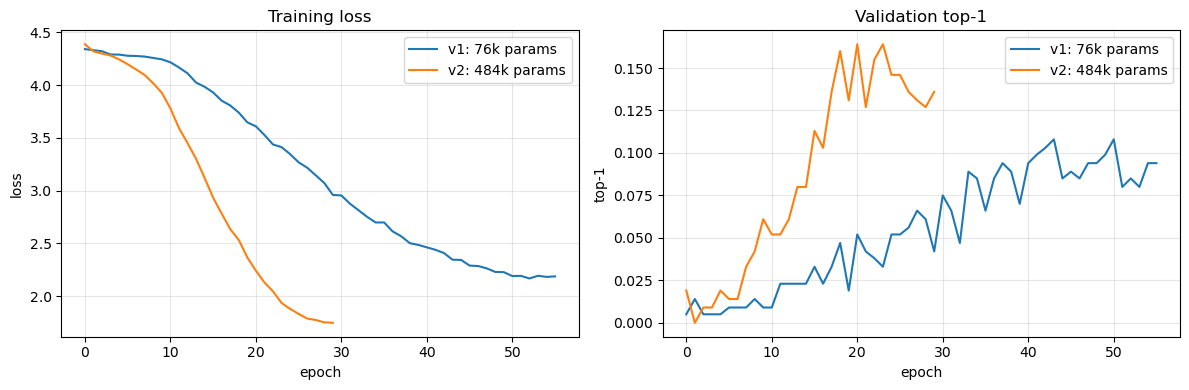

In [4]:
v1 = analysis.parse_log('artifacts/checkpoints/baseline/train.log')   # 76k params
v2 = analysis.parse_log('artifacts/checkpoints/baseline/probe.log')   # 484k params
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for v, lbl in [(v1, 'v1: 76k params'), (v2, 'v2: 484k params')]:
    e = [r[0] for r in v]
    ax[0].plot(e, [r[1] for r in v], label=lbl)
    ax[1].plot(e, [r[2] for r in v], label=lbl)
ax[0].set(title='Training loss', xlabel='epoch', ylabel='loss'); ax[0].legend()
ax[1].set(title='Validation top-1', xlabel='epoch', ylabel='top-1'); ax[1].legend()
plt.tight_layout(); plt.show()

## 4. Error analysis — where v2 actually stands

Capacity fixed the underfitting, but did it generalize? The numbers below tell the
real story.

Top-1 accuracy:  train 0.722 | val 0.164 | test 0.180


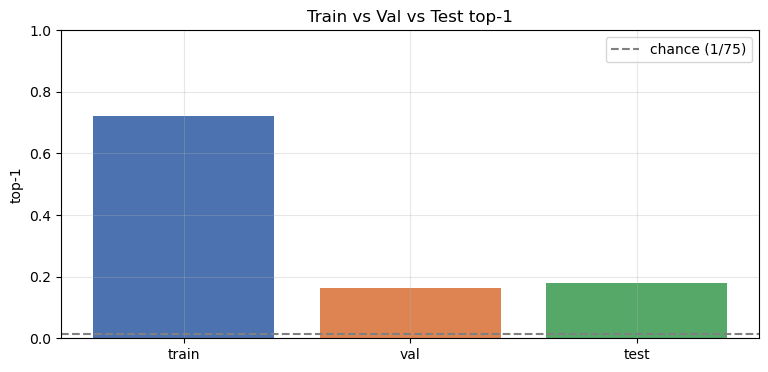

Train >> Test: a large gap = OVERFITTING. With ~23 training clips/class, data scarcity (not capacity) is now the wall.


In [5]:
R = analysis.run_analysis()      # runs the trained v2 checkpoint over all splits
acc = R['acc']
print('Top-1 accuracy:  train %.3f | val %.3f | test %.3f'
      % (acc['train'], acc['val'], acc['test']))
plt.bar(list(acc), list(acc.values()), color=['#4c72b0', '#dd8452', '#55a868'])
plt.axhline(1/len(labels), ls='--', c='gray', label='chance (1/75)')
plt.title('Train vs Val vs Test top-1'); plt.ylim(0, 1); plt.ylabel('top-1'); plt.legend()
plt.show()
print('Train >> Test: a large gap = OVERFITTING. With ~23 training clips/class,'
      ' data scarcity (not capacity) is now the wall.')

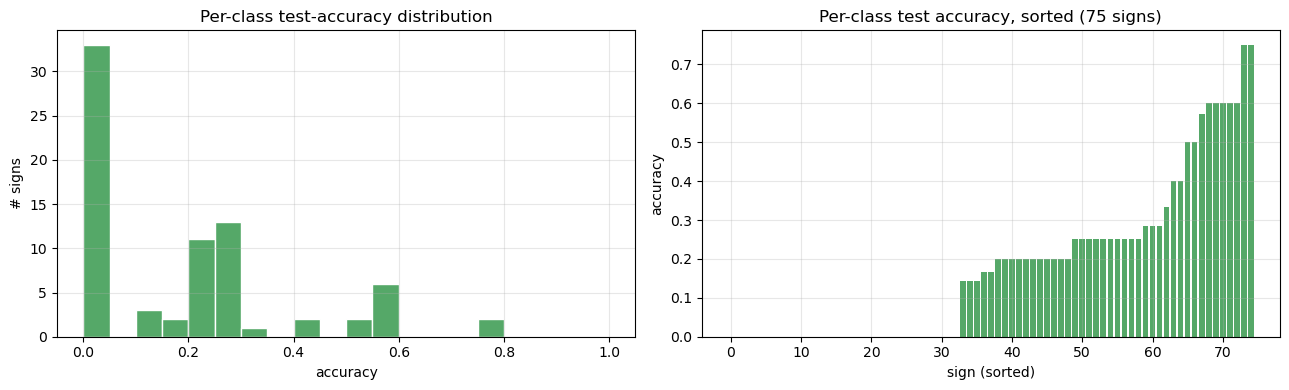

33/75 signs are at 0% test accuracy — the model gets a minority of signs and misses the long tail entirely.


In [6]:
pc = R['per_class']                       # per-class TEST accuracy (75 signs)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(pc, bins=20, range=(0, 1), color='#55a868', edgecolor='white')
ax[0].set(title='Per-class test-accuracy distribution', xlabel='accuracy', ylabel='# signs')
order = np.argsort(pc)
ax[1].bar(range(len(pc)), pc[order], color='#55a868')
ax[1].set(title='Per-class test accuracy, sorted (75 signs)',
          xlabel='sign (sorted)', ylabel='accuracy')
plt.tight_layout(); plt.show()
print(f'{int((pc == 0).sum())}/{len(pc)} signs are at 0% test accuracy — '
      'the model gets a minority of signs and misses the long tail entirely.')

Top-10 confused pairs  (true -> predicted, #clips):
    3   PLAY         -> DOG
    3   ORANGE       -> EAT
    3   NIGHT        -> WORK
    3   HOT          -> EAT
    2   WHO          -> EAT
    2   UNDERSTAND   -> EAT
    2   TIME         -> SISTER
    2   SORRY        -> SISTER
    2   PURPLE       -> DOG
    2   PLEASE       -> WELCOME

"Magnet" predicted classes: [('EAT', 4), ('DOG', 2), ('SISTER', 2)]
Several signs collapse onto a few classes (e.g. EAT) — consistent with an over-fit model defaulting to data-rich classes on unfamiliar test signers.


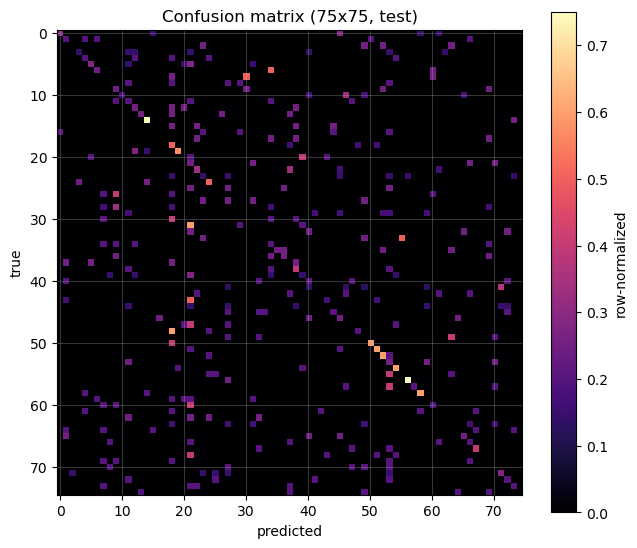

In [7]:
print('Top-10 confused pairs  (true -> predicted, #clips):')
for cnt, a, b in R['top_confused']:
    print(f'  {cnt:3d}   {a:12s} -> {b}')
mag = collections.Counter(b for _, _, b in R['top_confused'])
print('\n"Magnet" predicted classes:', mag.most_common(3))
print('Several signs collapse onto a few classes (e.g. EAT) — consistent with an'
      ' over-fit model defaulting to data-rich classes on unfamiliar test signers.')

cm = R['cm'].astype(float)
cmn = cm / cm.sum(1, keepdims=True).clip(min=1)
plt.figure(figsize=(7.5, 6.5))
plt.imshow(cmn, cmap='magma')
plt.colorbar(label='row-normalized')
plt.title('Confusion matrix (75x75, test)'); plt.xlabel('predicted'); plt.ylabel('true')
plt.show()

## 5. Diagnosis & roadmap

**Diagnosis.** v1 underfit (too small); v2 fits the training set (72%) but generalizes
poorly (18% test) — classic overfitting driven by **~23 training clips per class**.
The browser-export path is already de-risked (PyTorch -> ONNX round-trip verified;
quantized model ~0.5 MB, far under the 10 MB cap).

**Next levers, in order of expected impact:**
1. **Pretrain the encoder on a much larger ASL Citizen slice** (hundreds of signs) from
   scratch, then fine-tune the 75-class head — uses the abundant corpus to learn good
   hand/motion features instead of starving on 23 clips/class. (Still no external
   pretrained weights.)
2. **Classical (non-learned) ROI crop** — hands are tiny at 112px full-frame.
3. **Stronger augmentation + a Transformer temporal head** for motion-order cues.

**Honest framing for deployment:** the app uses a *conservative* per-class confidence
threshold (false-pass < 5%), so the product can be trustworthy even before accuracy is
high — it simply asks the learner to retry when unsure, rather than passing a guess.